In [44]:

import pandas as pd
import io
import matplotlib.pyplot as plt
import seaborn as sns


In [45]:
# Load CSV into a pandas DataFrame
df = pd.read_csv(r'D:\codingbase\data\Location1.csv')


# Load datasets
df1 = pd.read_csv(r'D:\codingbase\data\Location1.csv')
df2 = pd.read_csv(r'D:\codingbase\data\Location2.csv')
df3 = pd.read_csv(r'D:\codingbase\data\Location3.csv')
df4 = pd.read_csv(r'D:\codingbase\data\Location4.csv')   # optional, if needed separately





In [46]:
with open(r'D:\codingbase\data\readme.txt','r') as f:
    readme_content=f.read()
    print(readme_content)

The columns in the data are as follows:

Time - Hour of the day when readings occurred
temperature_2m - Temperature in degrees Fahrenheit at 2 meters above the surface
relativehumidity_2m - Relative humidity (as a percentage) at 2 meters above the surface
dewpoint_2m - Dew point in degrees Fahrenheit at 2 meters above the surface
windspeed_10m - Wind speed in meters per second at 10 meters above the surface
windspeed_100m - Wind speed in meters per second at 100 meters above the surface
winddirection_10m - Wind direction in degrees (0-360) at 10 meters above the surface (see notes)
winddirection_100m - Wind direction in degrees (0-360) at 100 meters above the surface (see notes)
windgusts_10m - Wind gusts in meters per second at 100 meters above the surface
Power - Turbine output, normalized to be between 0 and 1 (i.e., a percentage of maximum potential output)

Notes:
	1) Likely many of these variables will not be very relevant. They are included here but do not need to be included in

In [47]:
# Combine first three datasets vertically
combined_df = pd.concat([df1, df2, df3,df4], ignore_index=True)

# Quick check
combined_df.head()
combined_df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175200 entries, 0 to 175199
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Time                 175200 non-null  object 
 1   temperature_2m       175200 non-null  float64
 2   relativehumidity_2m  175200 non-null  int64  
 3   dewpoint_2m          175200 non-null  float64
 4   windspeed_10m        175200 non-null  float64
 5   windspeed_100m       175200 non-null  float64
 6   winddirection_10m    175200 non-null  int64  
 7   winddirection_100m   175200 non-null  int64  
 8   windgusts_10m        175200 non-null  float64
 9   Power                175200 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 13.4+ MB


In [48]:
df.columns[df.columns.duplicated()]


Index([], dtype='object')

In [49]:
combined_df.head()

,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
0,2017-01-02 00:00:00,28.5,85,24.5,1.44,1.26,146,162,1.4,0.1635
1,2017-01-02 01:00:00,28.4,86,24.7,2.06,3.99,151,158,4.4,0.1424
2,2017-01-02 02:00:00,26.8,91,24.5,1.30,2.78,148,150,3.2,0.1214
3,2017-01-02 03:00:00,27.4,88,24.3,1.30,2.69,58,105,1.6,0.1003
4,2017-01-02 04:00:00,27.3,88,24.1,2.47,4.43,58,84,4.0,0.0793


In [50]:
combined_df.info()



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 175200 entries, 0 to 175199
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   Time                 175200 non-null  object 
 1   temperature_2m       175200 non-null  float64
 2   relativehumidity_2m  175200 non-null  int64  
 3   dewpoint_2m          175200 non-null  float64
 4   windspeed_10m        175200 non-null  float64
 5   windspeed_100m       175200 non-null  float64
 6   winddirection_10m    175200 non-null  int64  
 7   winddirection_100m   175200 non-null  int64  
 8   windgusts_10m        175200 non-null  float64
 9   Power                175200 non-null  float64
dtypes: float64(6), int64(3), object(1)
memory usage: 13.4+ MB


In [51]:
combined_df.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000,175200.000000
mean,46.655994,70.155291,36.516241,4.157639,6.879334,201.589446,201.539070,8.038205,0.303429
std,22.012738,17.326678,20.933153,2.012682,3.043964,99.639040,100.683777,3.617488,0.257325
min,-31.200000,9.000000,-36.200000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000
25%,30.200000,57.000000,21.900000,2.630000,4.700000,130.000000,129.000000,5.300000,0.087700
50%,46.900000,72.000000,36.200000,3.850000,6.680000,211.000000,211.000000,7.600000,0.233100
75%,65.300000,84.000000,54.600000,5.380000,8.800000,288.000000,290.000000,10.300000,0.474200
max,101.700000,100.000000,78.700000,18.530000,24.590000,360.000000,360.000000,29.200000,0.999400


In [52]:
df1.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,47.862911,72.288744,38.569308,3.591147,6.284431,203.637329,203.343676,7.771795,0.405385
std,19.453691,16.852287,18.772110,1.649318,2.685216,96.371262,97.959852,3.569147,0.288322
min,-14.400000,18.000000,-17.100000,0.000000,0.100000,1.000000,0.000000,0.500000,0.000000
25%,32.100000,60.000000,24.300000,2.410000,4.380000,132.000000,130.000000,5.000000,0.148900
50%,47.300000,74.000000,38.100000,3.300000,6.080000,225.000000,226.000000,7.200000,0.347650
75%,64.500000,86.000000,54.700000,4.590000,7.990000,277.000000,278.000000,10.000000,0.659600
max,94.100000,100.000000,76.300000,13.450000,20.650000,360.000000,360.000000,29.200000,0.991300


In [53]:
df2.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,42.725605,69.085091,32.215932,4.693236,7.572439,208.512626,206.555594,8.557470,0.249902
std,23.724354,17.317481,21.307625,2.238572,3.381060,103.088845,104.882857,3.710385,0.209088
min,-31.200000,16.000000,-36.200000,0.000000,0.100000,1.000000,0.000000,0.500000,0.000000
25%,26.100000,56.000000,18.600000,3.010000,5.110000,135.000000,129.000000,5.800000,0.076200
50%,42.700000,71.000000,32.000000,4.440000,7.400000,224.000000,218.000000,8.200000,0.194950
75%,63.000000,83.000000,50.600000,6.040000,9.740000,300.000000,302.000000,10.800000,0.381800
max,95.400000,100.000000,76.600000,18.270000,24.590000,360.000000,360.000000,29.000000,0.985900


In [54]:
df3.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,49.225632,68.290708,38.225450,4.334103,7.047603,194.807100,194.897055,8.134600,0.307503
std,22.551070,17.865965,21.901316,2.061304,3.041665,101.823583,102.132837,3.661115,0.263879
min,-26.700000,12.000000,-35.500000,0.000000,0.000000,1.000000,0.000000,0.500000,0.000000
25%,32.000000,55.000000,22.800000,2.730000,4.880000,125.000000,126.000000,5.400000,0.077000
50%,50.300000,70.000000,38.100000,4.050000,6.920000,191.000000,193.000000,7.700000,0.240700
75%,68.400000,83.000000,57.900000,5.600000,8.990000,289.000000,289.000000,10.400000,0.498400
max,101.700000,100.000000,78.700000,18.530000,24.200000,360.000000,360.000000,26.600000,0.999400


In [55]:
df4.describe()

,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
count,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000,43800.000000
mean,46.809829,70.956621,37.054274,4.012071,6.612864,199.400731,201.359954,7.688954,0.250926
std,21.561586,16.969744,20.995804,1.887665,2.869876,96.575068,97.207775,3.458954,0.228814
min,-28.800000,9.000000,-35.600000,0.000000,0.000000,1.000000,1.000000,0.500000,0.000000
25%,30.300000,59.000000,21.900000,2.550000,4.580000,129.000000,130.000000,5.000000,0.066700
50%,47.100000,73.000000,37.100000,3.750000,6.500000,207.000000,211.000000,7.300000,0.184700
75%,65.400000,85.000000,55.300000,5.210000,8.440000,284.000000,286.000000,9.900000,0.371825
max,93.800000,100.000000,77.900000,14.260000,21.750000,360.000000,360.000000,26.400000,0.988800


In [56]:
print(combined_df.isnull().sum())

Time                   0
temperature_2m         0
relativehumidity_2m    0
dewpoint_2m            0
windspeed_10m          0
windspeed_100m         0
winddirection_10m      0
winddirection_100m     0
windgusts_10m          0
Power                  0
dtype: int64


In [57]:
combined_df.shape

(175200, 10)

In [58]:
combined_df['temperature_2m'].describe()

count    175200.000000
mean         46.655994
std          22.012738
min         -31.200000
25%          30.200000
50%          46.900000
75%          65.300000
max         101.700000
Name: temperature_2m, dtype: float64

In [59]:
combined_df[combined_df['temperature_2m'] < -25]


,Time,temperature_2m,relativehumidity_2m,dewpoint_2m,windspeed_10m,windspeed_100m,winddirection_10m,winddirection_100m,windgusts_10m,Power
61988,2019-01-29 20:00:00,-25.6,68,-32.8,7.34,11.24,336,336,11.3,0.5344
61989,2019-01-29 21:00:00,-26.0,70,-32.6,6.98,10.96,331,333,10.6,0.4821
61990,2019-01-29 22:00:00,-26.1,71,-32.4,6.57,10.62,327,330,10.0,0.4299
61991,2019-01-29 23:00:00,-26.5,72,-32.6,6.20,10.15,322,328,9.5,0.3776
61992,2019-01-30 00:00:00,-26.9,72,-32.9,5.61,9.63,320,327,8.8,0.3254
61993,2019-01-30 01:00:00,-27.8,73,-33.5,5.09,8.74,315,327,8.0,0.2731
61994,2019-01-30 02:00:00,-28.6,74,-34.1,4.78,7.90,307,322,7.1,0.2209
61995,2019-01-30 03:00:00,-29.4,74,-34.9,4.53,7.22,301,318,6.6,0.1686
61996,2019-01-30 04:00:00,-30.1,74,-35.5,4.49,6.65,291,313,6.2,0.1164
61997,2019-01-30 05:00:00,-30.5,74,-35.9,4.68,7.00,290,307,6.5,0.0840


In [60]:
# Apply value_counts() to the filtered column
cold_temp = combined_df['temperature_2m'][combined_df['temperature_2m']<-25]
cold_count=cold_temp.value_counts()
# Display the results
print(cold_count)

temperature_2m
-30.5    3
-26.9    3
-27.5    2
-26.4    2
-25.1    2
-28.2    2
-25.8    2
-26.0    1
-26.5    1
-25.6    1
-30.1    1
-29.4    1
-28.6    1
-27.8    1
-26.1    1
-31.2    1
-28.5    1
-30.8    1
-26.7    1
-25.5    1
-27.7    1
-25.4    1
-25.7    1
-27.3    1
-28.7    1
-28.8    1
Name: count, dtype: int64


<Axes: ylabel='temperature_2m'>

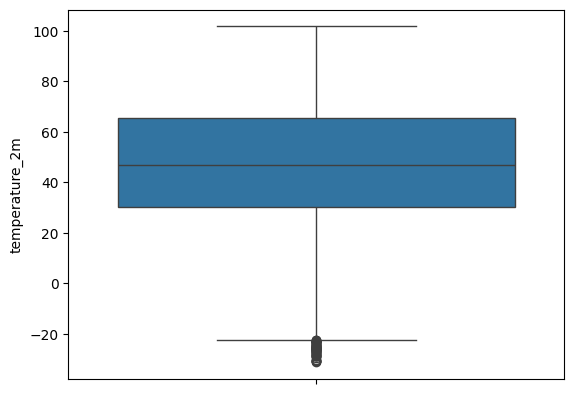

In [61]:
sns.boxplot(combined_df['temperature_2m'])

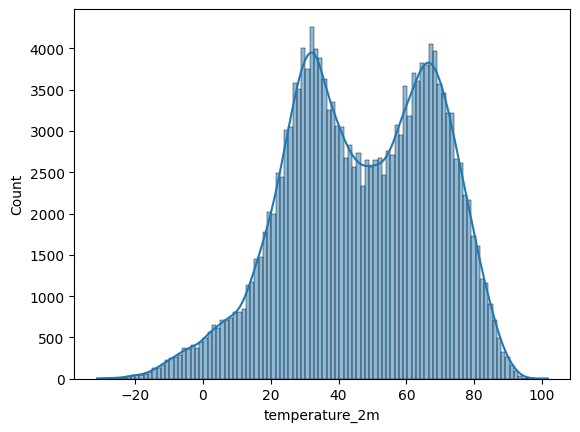

In [62]:
sns.histplot(combined_df['temperature_2m'],kde='true')
plt.show()

Temperature

-It is very lightly negatively skewed and so no need of balancing skewness

-It also has outliers to be managed*

In [63]:
median_temp = combined_df['temperature_2m'].median()
combined_df.loc[combined_df['temperature_2m'] < -25, 'temperature_2m'] = median_temp

<Axes: ylabel='temperature_2m'>

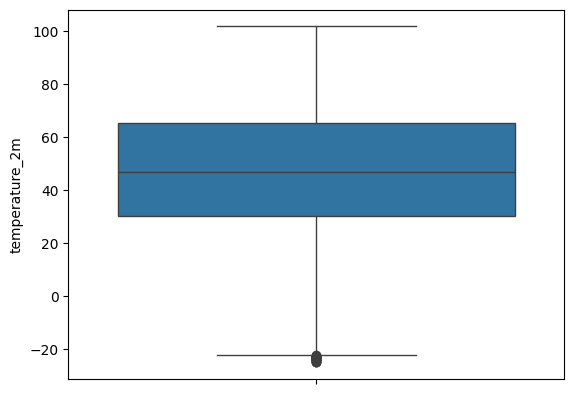

In [64]:
sns.boxplot(combined_df['temperature_2m'])

Now we have reduced the outliers in the dataset

In [65]:
combined_df['relativehumidity_2m'].describe()

count    175200.000000
mean         70.155291
std          17.326678
min           9.000000
25%          57.000000
50%          72.000000
75%          84.000000
max         100.000000
Name: relativehumidity_2m, dtype: float64

<Axes: ylabel='relativehumidity_2m'>

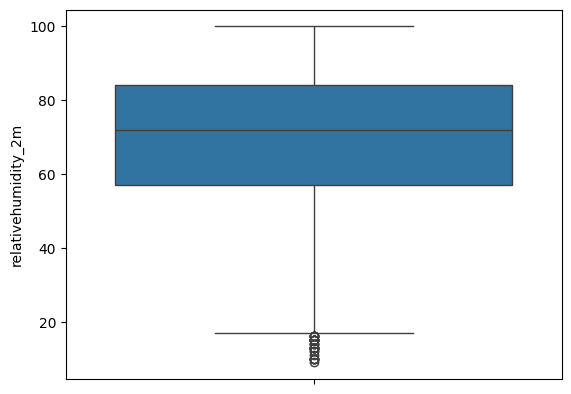

In [66]:
sns.boxplot(combined_df['relativehumidity_2m'])

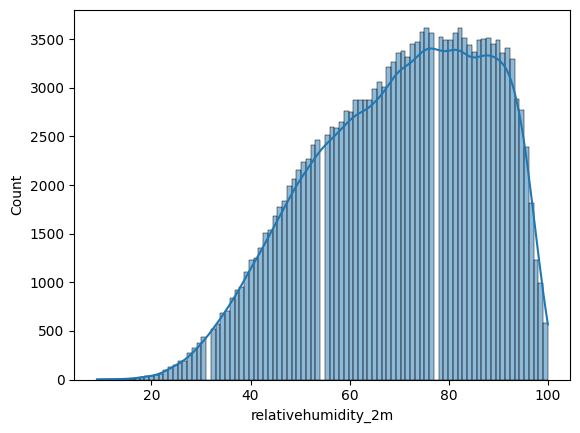

In [67]:
sns.histplot(combined_df['relativehumidity_2m'],kde='true')
plt.show()

In [68]:
combined_df['relativehumidity_2m'].skew()

np.float64(-0.3812417824751505)

Relative humidity

-The data seems to be negatively skewed but very lightly so no need of changing it

-The data has outliers to be managed*

In [69]:
# Assuming you have re-loaded or reset 'combined_df' to its original state

# 1. Recalculate robust bounds for Humidity (0-100 physical limits)
Q1_H, Q3_H = combined_df['relativehumidity_2m'].quantile([0.25, 0.75])
IQR_H = Q3_H - Q1_H
H_lower = max(0, Q1_H - 1.5 * IQR_H)
H_upper = min(100, Q3_H + 1.5 * IQR_H)

# 2. Apply Capping
combined_df.loc[combined_df['relativehumidity_2m'] < H_lower, 'relativehumidity_2m'] = H_lower
combined_df.loc[combined_df['relativehumidity_2m'] > H_upper, 'relativehumidity_2m'] = H_upper

C:\Users\Tanishq Sahu\AppData\Local\Temp\ipykernel_17188\1205313947.py:10: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '16.5' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  combined_df.loc[combined_df['relativehumidity_2m'] < H_lower, 'relativehumidity_2m'] = H_lower


<Axes: ylabel='relativehumidity_2m'>

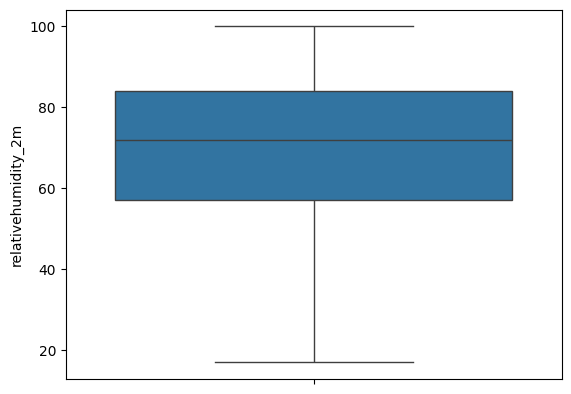

In [70]:
sns.boxplot(combined_df_cleaned['relativehumidity_2m'])

In [71]:
combined_df['dewpoint_2m'].describe()

count    175200.000000
mean         36.516241
std          20.933153
min         -36.200000
25%          21.900000
50%          36.200000
75%          54.600000
max          78.700000
Name: dewpoint_2m, dtype: float64

<Axes: ylabel='dewpoint_2m'>

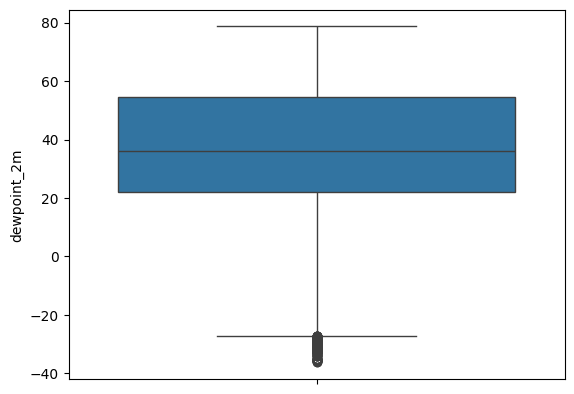

In [72]:
sns.boxplot(combined_df['dewpoint_2m'])

<Axes: xlabel='dewpoint_2m', ylabel='Count'>

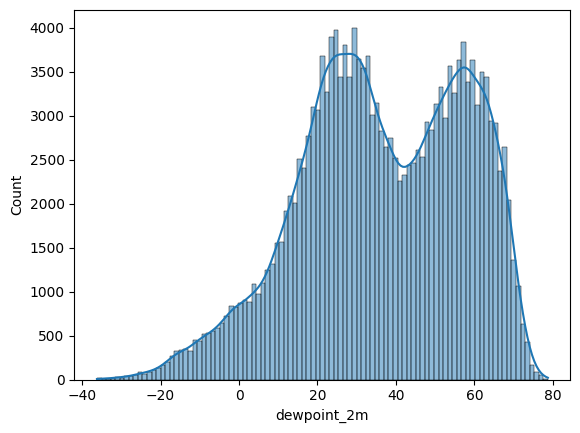

In [73]:
sns.histplot(combined_df['dewpoint_2m'],kde='true')


In [74]:
combined_df['dewpoint_2m'].skew()

np.float64(-0.33461955879521316)

<Axes: ylabel='dewpoint_2m'>

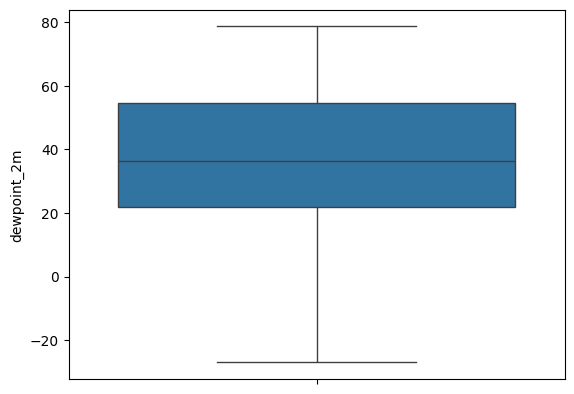

In [75]:
sns.boxplot(combined_df_cleaned['dewpoint_2m'])

In [76]:
equality_filter=combined_df_cleaned['temperature_2m']==combined_df_cleaned['dewpoint_2m']
equality_filter.sum()
equality_values=combined_df_cleaned[equality_filter]
print(equality_values)

                       Time  temperature_2m  relativehumidity_2m  dewpoint_2m  \
475     2017-01-21 19:00:00            40.4                  100         40.4   
477     2017-01-21 21:00:00            39.8                  100         39.8   
478     2017-01-21 22:00:00            40.4                  100         40.4   
479     2017-01-21 23:00:00            41.3                  100         41.3   
482     2017-01-22 02:00:00            38.8                  100         38.8   
...                     ...             ...                  ...          ...   
173190  2021-10-09 06:00:00            60.2                  100         60.2   
175024  2021-12-24 16:00:00            39.6                  100         39.6   
175025  2021-12-24 17:00:00            37.4                  100         37.4   
175026  2021-12-24 18:00:00            36.9                  100         36.9   
175028  2021-12-24 20:00:00            38.4                  100         38.4   

        windspeed_10m  wind

This shows that there are 286 times when the air has 100% vapour in it and temperature is equal to dew point

In [77]:
combined_df['windspeed_10m'].describe()

count    175200.000000
mean          4.157639
std           2.012682
min           0.000000
25%           2.630000
50%           3.850000
75%           5.380000
max          18.530000
Name: windspeed_10m, dtype: float64

<Axes: ylabel='windspeed_10m'>

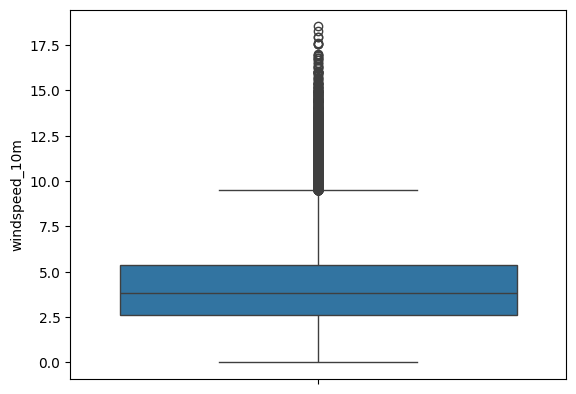

In [78]:
sns.boxplot(combined_df['windspeed_10m'])

<Axes: xlabel='windspeed_10m', ylabel='Count'>

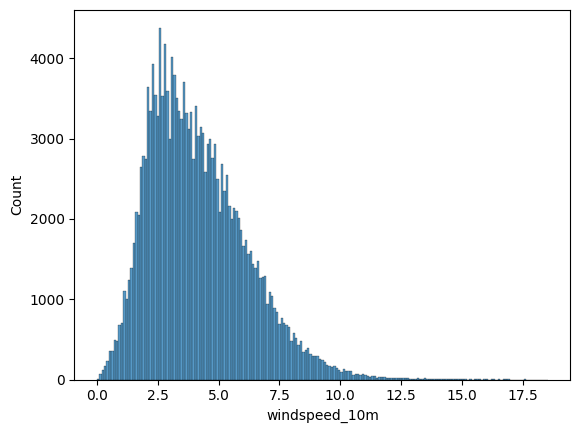

In [79]:
sns.histplot(combined_df['windspeed_10m'])

In [80]:
combined_df['windspeed_10m'].skew()

np.float64(0.8662191498595935)